# Interaction Tracking Analysis

Code to analyze the output from `interactionTracker.js`: process it to determine the likely interactions and reduce the amount of data, then produce some statistics.

In [1]:
from helpers import *


participants = [
    EvaluationData("P1", TaskOrder.T1T2, EvaluationTask.T1),
    EvaluationData("P2", TaskOrder.T1T2, EvaluationTask.T2),
    EvaluationData("P3", TaskOrder.T2T1, EvaluationTask.T2),
    EvaluationData("P4", TaskOrder.T1T2, EvaluationTask.T1),
    EvaluationData("P5", TaskOrder.T1T2, EvaluationTask.T2),
    EvaluationData("P6", TaskOrder.T2T1, EvaluationTask.T1),
    EvaluationData("P7", TaskOrder.T2T1, EvaluationTask.T1),
    EvaluationData("P8", TaskOrder.T2T1, EvaluationTask.T2),
    EvaluationData("P9", TaskOrder.T1T2, EvaluationTask.T2)
]

for participant in participants:
    filepath = os.getcwd() + f"/data/interactions_{participant.name}.json"
    interactionData = loadInteractionData(filepath)
    participant.interactionData = interactionData

In [2]:
# Load (refined) interaction data.
for participant in participants:
    print("\nParticipant " + participant.name)
    filepath = os.getcwd() + f"/data/interactions_{participant.name}.json"
    interactionData = loadInteractionData(filepath)
    participant.interactionData = refineInteractionData(interactionData)


Participant P1
Removed 37 invalid interaction entries!
Removed 12 duplicate interaction entries.

Participant P2
Removed 58 invalid interaction entries!

Participant P3
Removed 99 invalid interaction entries!
Removed 44 duplicate interaction entries.

Participant P4
Removed 21 invalid interaction entries!

Participant P5
Removed 165 invalid interaction entries!

Participant P6
Removed 117 invalid interaction entries!
Removed 42 duplicate interaction entries.

Participant P7
Removed 56 invalid interaction entries!

Participant P8
Removed 168 invalid interaction entries!
Removed 2 duplicate interaction entries.

Participant P9
Removed 25 invalid interaction entries!
Removed 3 duplicate interaction entries.


In [3]:
# Map interactions to correct tasks.
for participant in participants:
    interactionsFirstTask, interactionsSecondTask = splitInteractionsByTask(participant.interactionData)

    # only data for one task was tracked -> assume it was for task with extension active
    if not interactionsSecondTask:
        if participant.evalTask == EvaluationTask.T1:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = []
        else:
            participant.interactionsTaskOne = []
            participant.interactionsTaskTwo = interactionsFirstTask
    
    # ensure interactions are mapped to correct task
    else:
        if participant.taskOrder == TaskOrder.T1T2:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = interactionsSecondTask
        else:
            participant.interactionsTaskOne = interactionsSecondTask
            participant.interactionsTaskTwo = interactionsFirstTask

In [4]:
taskOneWithExtensionData = []
taskOneWithoutExtensionData = []
taskTwoWithExtensionData = []
taskTwoWithoutExtensionData = []

evaluationCounts = defaultdict(int)

for participant in participants:
    if participant.interactionsTaskOne:
        if participant.evalTask == EvaluationTask.T1:
            taskOneWithExtensionData.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithExtension"] += 1
        else:
            taskOneWithoutExtensionData.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithoutExtension"] += 1
    if participant.interactionsTaskTwo:
        if participant.evalTask == EvaluationTask.T2:
            taskTwoWithExtensionData.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithExtension"] += 1
        else:
            taskTwoWithoutExtensionData.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithoutExtension"] += 1

def combineInteractions(interactionsData):
    combinedInteractions = defaultdict(int)
    for participantData in interactionsData:
        for key, value in participantData.items():
            combinedInteractions[key] += value
    return combinedInteractions


taskOneWithExtension = combineInteractions(taskOneWithExtensionData)
taskOneWithoutExtension = combineInteractions(taskOneWithoutExtensionData)
taskTwoWithExtension = combineInteractions(taskTwoWithExtensionData)
taskTwoWithoutExtension = combineInteractions(taskTwoWithoutExtensionData)

print(f"Task one with extension count: {evaluationCounts['taskOneWithExtension']}")
print(f"Task one without extension count: {evaluationCounts['taskOneWithExtension']}")
print(f"Task two with extension count: {evaluationCounts['taskOneWithExtension']}")
print(f"Task two without extension count: {evaluationCounts['taskOneWithExtension']}")

print(taskOneWithExtension)
print(taskOneWithoutExtension)
print(taskTwoWithExtension)
print(taskTwoWithoutExtension)

# Insights: Switched view only rarely.

Task one with extension count: 4
Task one without extension count: 4
Task two with extension count: 4
Task two without extension count: 4
defaultdict(<class 'int'>, {'UnknownJump': 20, 'Scroll': 576, 'ChangeVisibleRanges': 116, 'ChangeFile': 56, 'ChangeSidebarVisibility': 10, 'EditingSession': 136, 'EditFile': 39, 'NavigationJump': 38, 'SwitchView': 2})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 3, 'ChangeFile': 70, 'ChangeVisibleRanges': 115, 'Scroll': 235, 'EditingSession': 45, 'EditFile': 24, 'UnknownJump': 11, 'NavigationJump': 21})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 9, 'ChangeFile': 180, 'Scroll': 534, 'ChangeVisibleRanges': 410, 'UnknownJump': 1893, 'EditingSession': 157, 'EditFile': 66, 'NavigationJump': 10, 'SwitchView': 1})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 3, 'Scroll': 419, 'ChangeFile': 40, 'UnknownJump': 57, 'ChangeVisibleRanges': 191, 'EditingSession': 74, 'EditFile': 31})


In [5]:
for participant in participants:
    print("\n--- Participant " + participant.name + " ---")

    if participant.interactionsTaskOne:
        print("\nTask One")
        print(countInteractions(participant.interactionsTaskOne))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskOne)}")
        print(f"Duration: {(participant.interactionsTaskOne[-1]['timeStamp'] - participant.interactionsTaskOne[0]['timeStamp']) / 1000}")

    if participant.interactionsTaskTwo:
        print("\nTask Two")
        print(countInteractions(participant.interactionsTaskTwo))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskTwo)}")
        print(f"Duration: {(participant.interactionsTaskTwo[-1]['timeStamp'] - participant.interactionsTaskTwo[0]['timeStamp']) / 1000}")


--- Participant P1 ---

Task One
defaultdict(<class 'int'>, {'UnknownJump': 10, 'Scroll': 148, 'ChangeVisibleRanges': 32, 'ChangeFile': 21, 'ChangeSidebarVisibility': 1, 'EditingSession': 57, 'EditFile': 11, 'NavigationJump': 8})
Scrolling Distance: 2194
Duration: 1648.144

--- Participant P2 ---

Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 27, 'Scroll': 52, 'ChangeVisibleRanges': 43, 'UnknownJump': 17, 'EditingSession': 38, 'EditFile': 16, 'NavigationJump': 2})
Scrolling Distance: 744
Duration: 1463.525

--- Participant P3 ---

Task Two
defaultdict(<class 'int'>, {'EditFile': 18, 'EditingSession': 54, 'ChangeFile': 47, 'ChangeVisibleRanges': 226, 'Scroll': 233, 'UnknownJump': 1822, 'ChangeSidebarVisibility': 3, 'NavigationJump': 4})
Scrolling Distance: 4808
Duration: 1611.695

--- Participant P4 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 5, 'ChangeVisibleRanges': 11, 'Scroll': 133, 'NavigationJump': 18, '

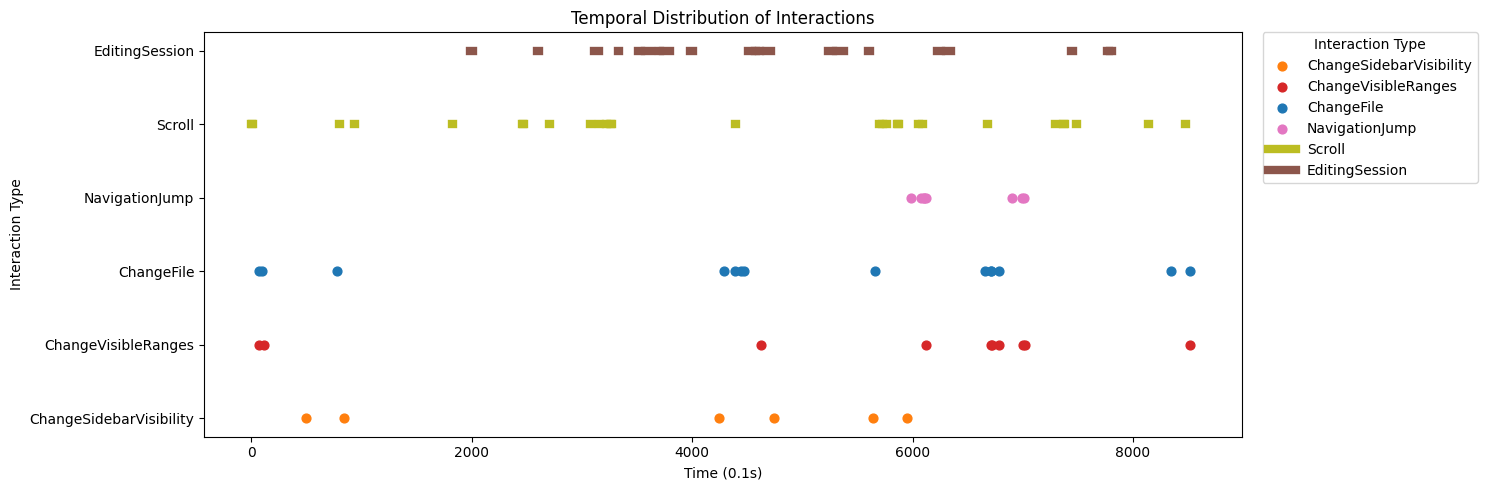

In [10]:
import matplotlib
import matplotlib.pyplot as plt

interactions = participants[6].interactionsTaskOne

interactions = [i for i in interactions if i['interactionType'] != "EditFile" and i['interactionType'] != "UnknownJump"]
interactions = remove_micronavigations(interactions, 6)

interactions_start = interactions[0]["timeStamp"]
for interaction in interactions:
    interaction["timeStamp"] = interaction["timeStamp"] - interactions_start
    if "startTime" in interaction:
         interaction["startTime"] = interaction["startTime"] - interactions_start
    if "endTime" in interaction:
         interaction["endTime"] = interaction["endTime"] - interactions_start

step_size = 100 # plot step size in ms

# Separate interactions
point_interactions = []
duration_interactions = []

for item in interactions:
    if 'startTime' in item and 'endTime' in item:
        duration_interactions.append({
            'type': item['interactionType'],
            'start': item['startTime'],
            'end': item['endTime']
        })
    elif 'timeStamp' in item:
        point_interactions.append({
            'type': item['interactionType'],
            'time': item['timeStamp'] / step_size
        })

# Unique interaction types
all_types = set([i['type'] for i in point_interactions + duration_interactions])

# Assign colors
color_map = matplotlib.colormaps['tab10']  # Use a standard colormap
type_to_color = {itype: color_map(i / len(all_types)) for i, itype in enumerate(sorted(all_types))}

# Create plot
fig, ax = plt.subplots(figsize=(15, 5))

# Plot point interactions
for i_type in all_types:
    times = [p['time'] for p in point_interactions if p['type'] == i_type]
    ax.scatter(
        times,
        [i_type] * len(times),
        label=f'{i_type}' if times else "",
        marker='o',
        s=40,
        color=type_to_color[i_type]
    )

# Plot duration interactions
for i_type in all_types:
    relevant = [d for d in duration_interactions if d['type'] == i_type]
    for i, d in enumerate(relevant):
        start, end = d['start'], d['end']
        if end - start < step_size:
            if (start + end) > step_size:
                end += step_size
            else:
                start -= step_size
        ax.plot(
            [start / step_size, end / step_size],
            [i_type, i_type],
            linewidth=6,
            color=type_to_color[i_type],
            label=f'{i_type}' if i == 0 else ""
        )

# Formatting
ax.set_xlabel("Time (0.1s)")
ax.set_ylabel("Interaction Type")
ax.legend(
    title="Interaction Type",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
plt.title("Temporal Distribution of Interactions")
plt.tight_layout()
plt.show()

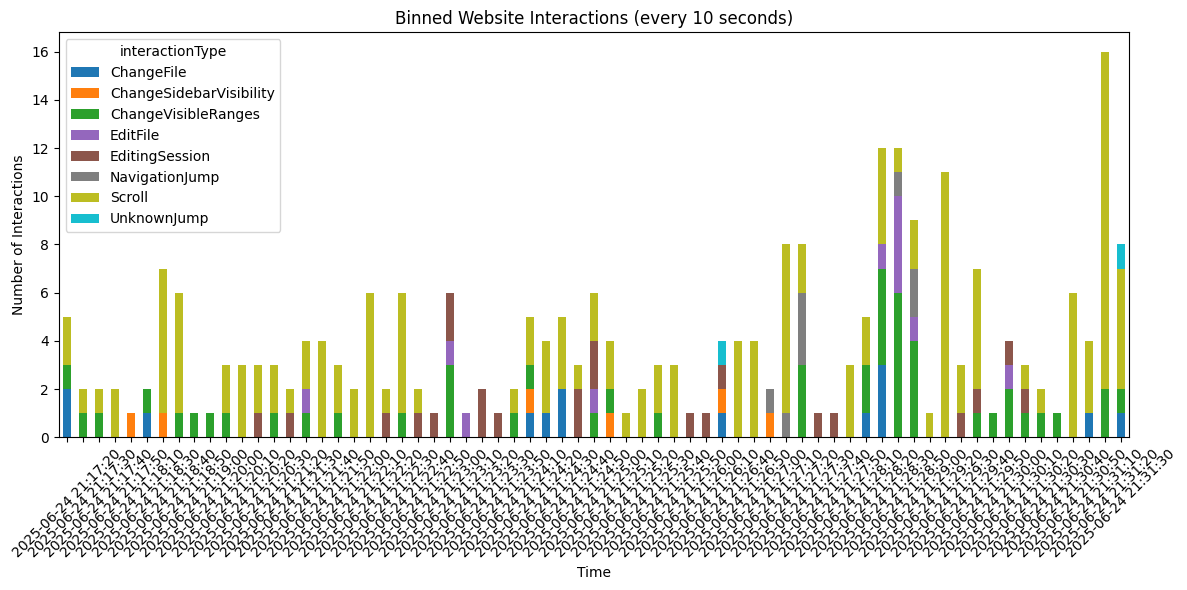

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

interactions = participants[6].interactionsTaskOne

# Convert timestamps and flatten into DataFrame with one datetime column
def ms_to_dt(ms): return datetime.fromtimestamp(ms / 1000.0)

flattened = []
for i in interactions:
    if 'startTime' in i:
        flattened.append({
            'datetime': ms_to_dt(i['startTime']),
            'interactionType': i['interactionType']
        })
    elif 'timeStamp' in i:
        flattened.append({
            'datetime': ms_to_dt(i['timeStamp']),
            'interactionType': i['interactionType']
        })

df = pd.DataFrame(flattened)

# Set bin size (10 seconds)
bin_size = '10S'  # '10S' for 10 seconds, '1Min' for 1 minute, etc.

# Round timestamps into bins
df['time_bin'] = pd.to_datetime(df['datetime']).dt.floor(bin_size)

# Count interactions per type per bin
agg_df = df.groupby(['time_bin', 'interactionType']).size().unstack(fill_value=0)

# Plot
agg_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

plt.xlabel("Time")
plt.ylabel("Number of Interactions")
plt.title("Binned Website Interactions (every 10 seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
